# Maybe a more efficient way of getting Colloidal vs Particulate profiles in the WC

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from matplotlib.path import Path
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path


In [2]:
path = {'coords' : '/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
'mask' : '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc',
'bathy' : '/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [3]:
jjii = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [4]:
stations = ['JF2', 'HS', 'S4-1.5', 'S2', 'NG', 'S1 (plume)', 'S3', 'FR']
lat = np.array([48 + (18/60), 48 + (37.80/60) , 49 + (15/60) , 49 + (17.58/60) , 49 + (43.60/60), 49 + (12.32/60), 49 + (17.88/60), 49 + (08.66/60)])
lon = (-1) * np.array([124, 123 + (14.60/60), 123 + (40/60), 123 + (22.51/60), 124 + (40.80/60), 123 + (18/60), 123 + (04.91/60), 123 + (02.65/60)]) 
#
x_obs = np.zeros_like(lon, dtype=int)
y_obs = np.zeros_like(lat, dtype=int)
for j in range(len(lon)):
    jj, ii = finder(lat[j], lon[j])
    x_obs[j] = ii
    y_obs[j] = jj

In [5]:
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)

divide data per perticles depth ranges (0-10), (10-20), etc... Then ger the particles inside polygon and apply the rest... Automate so it's actually faster and more efficient

In [6]:
filenames = [f'/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_{i}.nc' for i in range(1, 13)]

# Time binned per depth

In [7]:
def get_binned_timeseries_multi(filenames, polygon_coords, 
                                z_var='z', lon_var='lon', lat_var='lat', status_var='status', 
                                target_status=None, step=10, cumulative=False):
    
    if isinstance(filenames, str):
        filenames = [filenames]
        
    poly_path = Path(polygon_coords)
    all_dfs = []
    
    for filename in filenames:
        timeseries_dict = {}
        
        with xr.open_dataset(filename) as data:
            z_vals = data[z_var].values
            lon_vals = data[lon_var].values
            lat_vals = data[lat_var].values
            
            n_obs = z_vals.shape[1] 
            
            if target_status is not None:
                status_vals = data[status_var].values
                if isinstance(target_status, (list, tuple, np.ndarray)):
                    status_mask = np.isin(status_vals, target_status)
                else:
                    status_mask = status_vals == target_status
            else:
                status_mask = np.ones_like(z_vals, dtype=bool)
            
            if not np.any(status_mask):
                all_dfs.append(pd.DataFrame())
                continue
                
            min_depth = np.nanmin(z_vals[status_mask])
            max_depth = np.nanmax(z_vals[status_mask])
            current_z = np.floor(min_depth / step) * step
            
            while current_z < max_depth:
                next_z = current_z + step
                bin_label = f"{int(current_z)}-{int(next_z)}"
                
                depth_mask = (z_vals >= current_z) & (z_vals < next_z)
                valid_mask = status_mask & depth_mask
                
                counts_per_time = np.zeros(n_obs, dtype=int)
                
                if np.any(valid_mask):
                    valid_lon = lon_vals[valid_mask]
                    valid_lat = lat_vals[valid_mask]
                    points = np.column_stack((valid_lon, valid_lat))
                    inside_poly = poly_path.contains_points(points)
                    
                    if np.any(inside_poly):
                        valid_obs_idx = np.where(valid_mask)[1]
                        inside_obs_idx = valid_obs_idx[inside_poly]
                        counts_per_time = np.bincount(inside_obs_idx, minlength=n_obs)
                
                timeseries_dict[bin_label] = counts_per_time
                current_z = next_z
                
        all_dfs.append(pd.DataFrame(timeseries_dict))
        
    if not all_dfs:
        return pd.DataFrame()
        
    if cumulative:
        combined_dfs = [all_dfs[0]]
        for i in range(1, len(all_dfs)):
            # Superimposes Year 1 (baseline release) onto every subsequent year
            current_total = all_dfs[i].add(all_dfs[0], fill_value=0)
            combined_dfs.append(current_total)
        final_df = pd.concat(combined_dfs, ignore_index=True)
    else:
        final_df = pd.concat(all_dfs, ignore_index=True)
        
    final_df = final_df.fillna(0)
    
    return final_df

# SSOG

In [8]:
from Regions_functions_V2 import polygon_S1, polygon_lon_lat_S1

# Colloidal (Status 2)

In [9]:
full_timeseries_S1_C = get_binned_timeseries_multi(filenames, polygon_lon_lat_S1, target_status = 2, cumulative = True)

In [10]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_C = pd.DataFrame({
    'Mean_Count': full_timeseries_S1_C.mean(),
    'Std_Dev': full_timeseries_S1_C.std()
})

# Make the index name clean
final_stats_C.index.name = 'Depth_Bin'

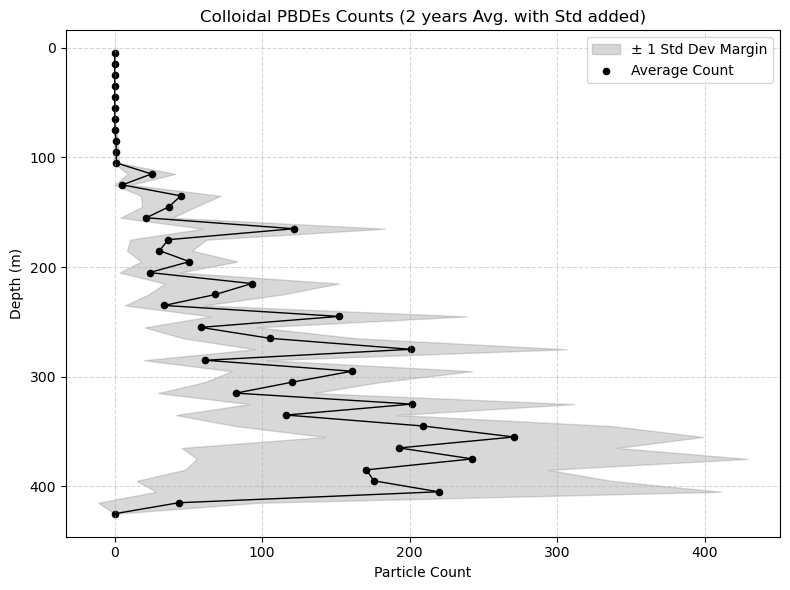

In [11]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in final_stats_C.index])

# Extract values
mean_count = final_stats_C['Mean_Count'].values
std_dev = final_stats_C['Std_Dev'].values

plt.figure(figsize=(8, 6))

# 2. Plot the shaded +/- std margin
plt.fill_betweenx(
    y_midpoints, 
    mean_count - std_dev, 
    mean_count + std_dev, 
    color='gray', 
    alpha=0.3, 
    label='± 1 Std Dev Margin'
)

# 3. Plot the basic average line with dots at the exact bin midpoints
# 'k-o' creates a black line with circular markers
plt.scatter(mean_count, y_midpoints, marker = 'o', s = 20, c = 'k', label='Average Count')
plt.plot(mean_count, y_midpoints,'k', linewidth = 1)


# 4. Format the plot
plt.gca().invert_yaxis()  # Depth goes down
plt.xlabel('Particle Count')
plt.ylabel('Depth (m)')
plt.title('Colloidal PBDEs Counts (2 years Avg. with Std added)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Particulate (Status 1 and 3)

In [12]:
full_timeseries_S1_P = get_binned_timeseries_multi(filenames, polygon_lon_lat_S1, target_status = [1,3], cumulative = True)

In [13]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_P = pd.DataFrame({
    'Mean_Count': full_timeseries_S1_P.mean(),
    'Std_Dev': full_timeseries_S1_P.std()
})

# Make the index name clean
final_stats_P.index.name = 'Depth_Bin'

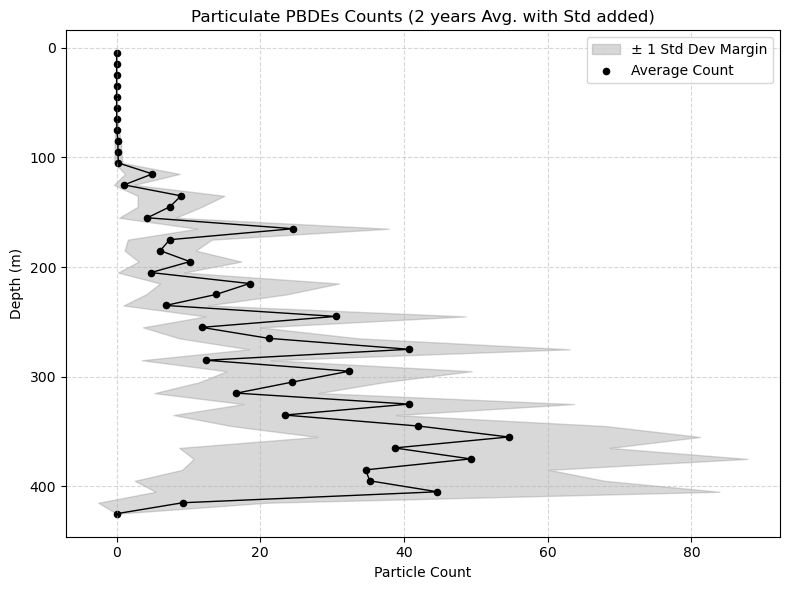

In [14]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in final_stats_P.index])

# Extract values
mean_count = final_stats_P['Mean_Count'].values
std_dev = final_stats_P['Std_Dev'].values

plt.figure(figsize=(8, 6))

# 2. Plot the shaded +/- std margin
plt.fill_betweenx(
    y_midpoints, 
    mean_count - std_dev, 
    mean_count + std_dev, 
    color='gray', 
    alpha=0.3, 
    label='± 1 Std Dev Margin'
)

# 3. Plot the basic average line with dots at the exact bin midpoints
# 'k-o' creates a black line with circular markers
plt.scatter(mean_count, y_midpoints, marker = 'o', s = 20, c = 'k', label='Average Count')
plt.plot(mean_count, y_midpoints,'k', linewidth = 1)


# 4. Format the plot
plt.gca().invert_yaxis()  # Depth goes down
plt.xlabel('Particle Count')
plt.ylabel('Depth (m)')
plt.title('Particulate PBDEs Counts (2 years Avg. with Std added)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [15]:
depth_avg_S4_15_0 = [25, 25, 25, 25, 25, 25, 25, 25, 25, 25]
part_S4_15_0 = [0.2, 1.6, 0.2, 0.7, 0.9, 1.1, 2.5, 2.6, 0.4, 1.0]
#
depth_avg_S4_15_1 = [150, 150, 150, 150, 150, 150, 150, 150, 150, 150]
part_S4_15_1 = [0.2, 1.2, 2.0, 6.6, 1.1, 1.4, 0.1, 1.2, 0.4, 1.0]
#
depth_deep = depth_avg_S4_15_1[0]
depth_shallow = depth_avg_S4_15_0[0]
part_S4_15_0_comp = [100 - v for v in part_S4_15_0]
part_S4_15_1_comp = [100 - v for v in part_S4_15_1]

In [16]:
ts_total = full_timeseries_S1_C + full_timeseries_S1_P

In [17]:
ts_pct_C = (full_timeseries_S1_C / ts_total) * 100
ts_pct_P = (full_timeseries_S1_P / ts_total) * 100

# 3. Calculate the true Mean and Standard Deviation of those percentages
true_stats_C = pd.DataFrame({
    'Mean_Pct': ts_pct_C.mean(),
    'Std_Pct': ts_pct_C.std()
})
true_stats_C.index.name = 'Depth_Bin'

true_stats_P = pd.DataFrame({
    'Mean_Pct': ts_pct_P.mean(),
    'Std_Pct': ts_pct_P.std()
})
true_stats_P.index.name = 'Depth_Bin'

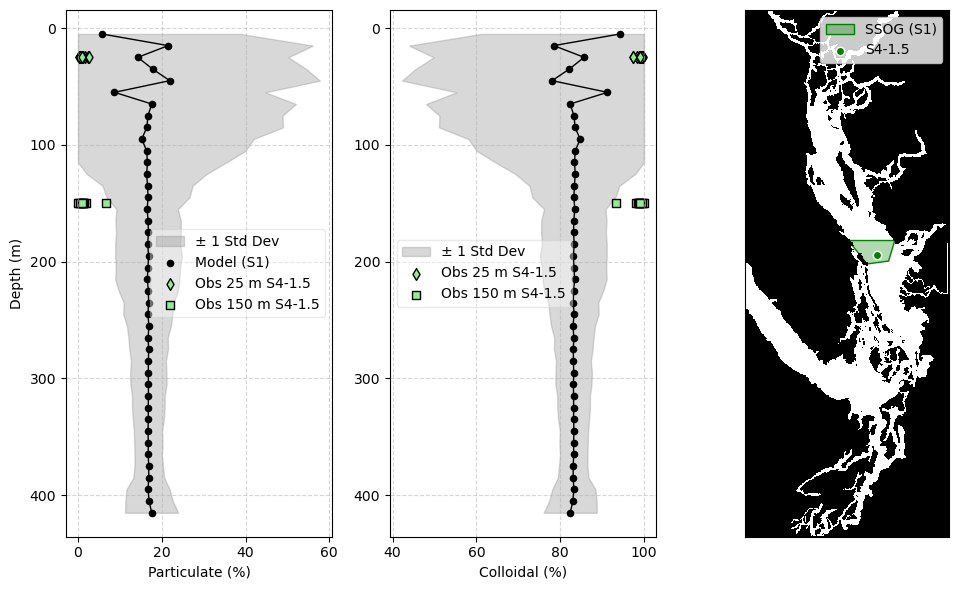

In [18]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in true_stats_C.index])

window_size = 5

# Colloidal
mean_C = true_stats_C['Mean_Pct']
std_C_smooth = true_stats_C['Std_Pct'].rolling(window=window_size, center=True, min_periods=1).mean()
lower_C = np.clip(mean_C - std_C_smooth, 0, 100)
upper_C = np.clip(mean_C + std_C_smooth, 0, 100)

# Particulate
mean_P = true_stats_P['Mean_Pct']
std_P_smooth = true_stats_P['Std_Pct'].rolling(window=window_size, center=True, min_periods=1).mean()
lower_P = np.clip(mean_P - std_P_smooth, 0, 100)
upper_P = np.clip(mean_P + std_P_smooth, 0, 100)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 6))

ax1.fill_betweenx(
    y_midpoints, lower_P, upper_P, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax1.scatter(mean_P, y_midpoints, marker='o', s=20, c='k', label='Model (S1)')
ax1.plot(mean_P, y_midpoints, 'k', linewidth=1)

ax1.scatter(part_S4_15_0, depth_avg_S4_15_0, c='lightgreen', marker='d', edgecolor='k', label=f'Obs {depth_shallow} m S4-1.5')
ax1.scatter(part_S4_15_1, depth_avg_S4_15_1, c='lightgreen', marker='s', edgecolor='k', label=f'Obs {depth_deep} m S4-1.5')

ax1.set_xlabel('Particulate (%)')
ax1.set_ylabel('Depth (m)')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.fill_betweenx(
    y_midpoints, lower_C, upper_C, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax2.scatter(mean_C, y_midpoints, marker='o', s=20, c='k')
ax2.plot(mean_C, y_midpoints, 'k', linewidth=1)

ax2.scatter(part_S4_15_0_comp, depth_avg_S4_15_0, c='lightgreen', marker='d', edgecolor='k', label=f'Obs {depth_shallow} m S4-1.5')
ax2.scatter(part_S4_15_1_comp, depth_avg_S4_15_1, c='lightgreen', marker='s', edgecolor='k', label=f'Obs {depth_deep} m S4-1.5')

ax2.set_xlabel('Colloidal (%)')
ax2.grid(True, linestyle='--', alpha=0.5)

plot_polygon(polygon_S1, ax=ax3, color='g', label='SSOG (S1)', add_points=False)
ax3.pcolormesh(mask['tmask'][0][0], cmap=cmap)
ax3.scatter(x_obs[2], y_obs[2], marker='o', edgecolors='w', c='g', label=stations[2])
ax3.tick_params(which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

f = 1.14
ax3.set_aspect(f)
ax3.legend(loc='upper right')

for ax in [ax1, ax2]:
    ax.invert_yaxis()
    ax.legend(framealpha=.4)

plt.tight_layout()
plt.show()

# NSOG

In [19]:
from Regions_functions_V2 import polygon_N1, polygon_lon_lat_N1

In [20]:
depth_avg_NG_0 = [25, 25]
part_NG_0 = [5, 15]
#
depth_avg_NG_1 = [150, 150]
part_NG_1 = [11, 55]
#
depth_shallow = depth_avg_NG_0[1]
depth_deep = depth_avg_NG_1[0]

In [21]:
full_timeseries_N1_C = get_binned_timeseries_multi(filenames, polygon_lon_lat_N1, target_status = 2, cumulative = True)

In [22]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_C = pd.DataFrame({
    'Mean_Count': full_timeseries_N1_C.mean(),
    'Std_Dev': full_timeseries_N1_C.std(),
})

# Make the index name clean
final_stats_C.index.name = 'Depth_Bin'

In [23]:
full_timeseries_N1_P = get_binned_timeseries_multi(filenames, polygon_lon_lat_N1, target_status = [1,3], cumulative = True)

In [24]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_P = pd.DataFrame({
    'Mean_Count': full_timeseries_N1_P.mean(),
    'Std_Dev': full_timeseries_N1_P.std()
})

# Make the index name clean
final_stats_P.index.name = 'Depth_Bin'

In [25]:
ts_total = full_timeseries_N1_C + full_timeseries_N1_P

In [26]:
ts_pct_C = (full_timeseries_N1_C / ts_total) * 100
ts_pct_P = (full_timeseries_N1_P / ts_total) * 100

# 3. Calculate the true Mean and Standard Deviation of those percentages
true_stats_C = pd.DataFrame({
    'Mean_Pct': ts_pct_C.mean(),
    'Std_Pct': ts_pct_C.std()
})
true_stats_C.index.name = 'Depth_Bin'

true_stats_P = pd.DataFrame({
    'Mean_Pct': ts_pct_P.mean(),
    'Std_Pct': ts_pct_P.std()
})
true_stats_P.index.name = 'Depth_Bin'

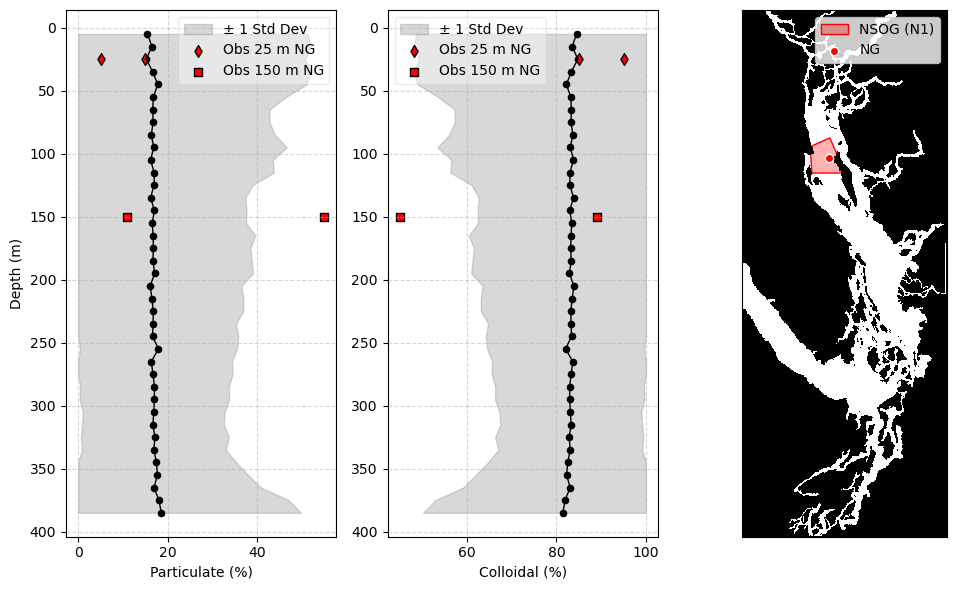

In [27]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in true_stats_C.index])

# 2. Extract means and apply a Pandas Rolling Average to smooth the Standard Deviation
window_size = 3  # Increase this number (e.g., 5) if you want even smoother edges

# Particulate
mean_P = true_stats_P['Mean_Pct']
std_P_smooth = true_stats_P['Std_Pct'].rolling(window=window_size, center=True, min_periods=1).mean()
lower_P = np.clip(mean_P - std_P_smooth, 0, 100)
upper_P = np.clip(mean_P + std_P_smooth, 0, 100)

# Colloidal
mean_C = true_stats_C['Mean_Pct']
std_C_smooth = true_stats_C['Std_Pct'].rolling(window=window_size, center=True, min_periods=1).mean()
lower_C = np.clip(mean_C - std_C_smooth, 0, 100)
upper_C = np.clip(mean_C + std_C_smooth, 0, 100)

# 3. Create the figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 6))

# --- Plot 1: Particulate ---
ax1.fill_betweenx(
    y_midpoints, lower_P, upper_P, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax1.scatter(mean_P, y_midpoints, marker='o', s=20, c='k')
ax1.plot(mean_P, y_midpoints, 'k', linewidth=1)

# OBS
ax1.scatter(part_NG_0, depth_avg_NG_0, c='r', marker='d', edgecolor='k', label=f'Obs {depth_shallow} m NG')
ax1.scatter(part_NG_1, depth_avg_NG_1, c='r', marker='s', edgecolor='k', label=f'Obs {depth_deep} m NG')

ax1.set_xlabel('Particulate (%)')
ax1.set_ylabel('Depth (m)')
#ax1.set_title('Particulate PBDEs')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Colloidal ---
ax2.fill_betweenx(
    y_midpoints, lower_C, upper_C, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax2.scatter(mean_C, y_midpoints, marker='o', s=20, c='k')
ax2.plot(mean_C, y_midpoints, 'k', linewidth=1)

# OBS
part_NG_0_comp = [100 - v for v in part_NG_0]
part_NG_1_comp = [100 - v for v in part_NG_1]
ax2.scatter(part_NG_0_comp, depth_avg_NG_0, c='r', marker='d', edgecolor='k', label=f'Obs {depth_shallow} m NG')
ax2.scatter(part_NG_1_comp, depth_avg_NG_1, c='r', marker='s', edgecolor='k', label=f'Obs {depth_deep} m NG')

ax2.set_xlabel('Colloidal (%)')
#ax2.set_title('Colloidal PBDEs')
ax2.grid(True, linestyle='--', alpha=0.5)

# --- Plot 3: Map/Polygon ---
# ax1.set_xlim(0, 60)
# ax2.set_xlim(50, 100)
plot_polygon(polygon_N1, ax=ax3, color='r', label='NSOG (N1)', add_points=False)
# ax3.scatter(points_x_N2, points_y_N2, c=colors_regions[6], s=20, marker='s')
# ax3.scatter(points_x_N3, points_y_N3, c=colors_regions[6], s=20, marker='s')

ax3.pcolormesh(mask['tmask'][0][0], cmap=cmap)
ax3.scatter(x_obs[4], y_obs[4], marker='o', edgecolors='w', c='r', label=stations[4])
ax3.tick_params(which='both', bottom=False, top=False, left=False, right=False,
                labelbottom=False, labelleft=False)
f = 1.14
ax3.set_aspect(f)
ax3.legend(loc='upper right')

# --- Formatting ---
for ax in [ax1, ax2]:
    ax.invert_yaxis()
    ax.legend(framealpha=.4)    

plt.tight_layout()
plt.show()

# Iona Plume

In [28]:
from Regions_functions_V2 import polygon_SP, polygon_lon_lat_SP

In [29]:
depth_avg_S1 = [60, 60]
part_S1 = [17, 29]
#
depth_avg_S2_0 = [50, 50, 50, 50]
part_S2_0 = [14, 15, 0.1, 0.5]
#
depth_avg_S2_1 = [60, 60]
part_S2_1 = [0.4, 2.3]

In [30]:
depth_S1 = depth_avg_S1
part_S1 = part_S1
# S2 
depth_S2 = depth_avg_S2_0 + depth_avg_S2_1
part_S2 = part_S2_0 + part_S2_1

In [31]:
full_timeseries_SP_C = get_binned_timeseries_multi(filenames, polygon_lon_lat_SP, target_status = 2, cumulative = True)

In [32]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_C = pd.DataFrame({
    'Mean_Count': full_timeseries_SP_C.mean(),
    'Std_Dev': full_timeseries_SP_C.std()
})

# Make the index name clean
final_stats_C.index.name = 'Depth_Bin'

In [33]:
full_timeseries_SP_P = get_binned_timeseries_multi(filenames, polygon_lon_lat_SP, target_status = [1,3], cumulative = True)

In [34]:
# 4. Calculate Mean and Standard Deviation per depth bin
final_stats_P = pd.DataFrame({
    'Mean_Count': full_timeseries_SP_P.mean(),
    'Std_Dev': full_timeseries_SP_P.std()
})

# Make the index name clean
final_stats_P.index.name = 'Depth_Bin'

In [35]:
ts_total = full_timeseries_SP_C + full_timeseries_SP_P

In [36]:
ts_pct_C = (full_timeseries_SP_C / ts_total) * 100
ts_pct_P = (full_timeseries_SP_P / ts_total) * 100

# 3. Calculate the true Mean and Standard Deviation of those percentages
true_stats_C = pd.DataFrame({
    'Mean_Pct': ts_pct_C.mean(),
    'Std_Pct': ts_pct_C.std()
})
true_stats_C.index.name = 'Depth_Bin'

true_stats_P = pd.DataFrame({
    'Mean_Pct': ts_pct_P.mean(),
    'Std_Pct': ts_pct_P.std()
})
true_stats_P.index.name = 'Depth_Bin'

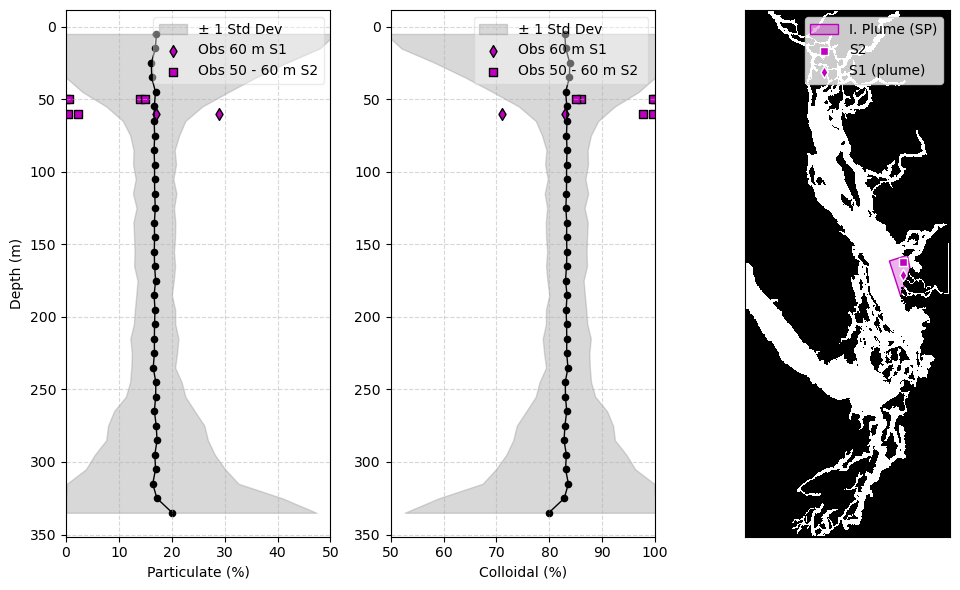

In [37]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in true_stats_C.index])

# 2. Extract means and apply a Pandas Rolling Average to smooth the Standard Deviation
window_size = 3  # Increase this number (e.g., 5) if you want even smoother edges

# Particulate
mean_P = true_stats_P['Mean_Pct']
std_P_smooth = true_stats_P['Std_Pct'].rolling(window=window_size, center=True, min_periods=1).mean()
lower_P = np.clip(mean_P - std_P_smooth, 0, 100)
upper_P = np.clip(mean_P + std_P_smooth, 0, 100)

# Colloidal
mean_C = true_stats_C['Mean_Pct']
std_C_smooth = true_stats_C['Std_Pct'].rolling(window=window_size, center=True, min_periods=1).mean()
lower_C = np.clip(mean_C - std_C_smooth, 0, 100)
upper_C = np.clip(mean_C + std_C_smooth, 0, 100)

# 3. Create the figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 6))

# --- Plot 1: Particulate ---
ax1.fill_betweenx(
    y_midpoints, lower_P, upper_P, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax1.scatter(mean_P, y_midpoints, marker='o', s=20, c='k')
ax1.plot(mean_P, y_midpoints, 'k', linewidth=1)

# OBS
ax1.scatter(part_S1, depth_S1, c='m', marker='d', edgecolor='k', label=f'Obs {depth_S1[0]} m S1')
ax1.scatter(part_S2, depth_S2, c='m', marker='s', edgecolor='k', label=f'Obs {depth_S2[0]} - {depth_S2[-1]} m S2')

ax1.set_xlabel('Particulate (%)')
ax1.set_ylabel('Depth (m)')
#ax1.set_title('Particulate PBDEs')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Colloidal ---
ax2.fill_betweenx(
    y_midpoints, lower_C, upper_C, 
    color='gray', alpha=0.3, label='± 1 Std Dev'
)
ax2.scatter(mean_C, y_midpoints, marker='o', s=20, c='k')
ax2.plot(mean_C, y_midpoints, 'k', linewidth=1)

# OBS
part_S1_comp = [100 - p for p in part_S1]
part_S2_comp = [100 - p for p in part_S2]
ax2.scatter(part_S1_comp, depth_S1, c='m', marker='d', edgecolor='k', label=f'Obs {depth_S1[0]} m S1 ')
ax2.scatter(part_S2_comp, depth_S2, c='m', marker='s', edgecolor='k', label=f'Obs {depth_S2[0]} - {depth_S2[-1]} m S2 ')

ax2.set_xlabel('Colloidal (%)')
#ax2.set_title('Colloidal PBDEs')
ax2.grid(True, linestyle='--', alpha=0.5)

ax1.set_xlim(0, 50)
ax2.set_xlim(50, 100)

# --- Plot 3: Map/Polygon ---
plot_polygon(polygon_SP, ax=ax3, color='m', label='I. Plume (SP)', add_points=False)
#ax3.scatter(points_x_N2, points_y_N2, c=colors_regions[6], s=20, marker='s')
#ax3.scatter(points_x_N3, points_y_N3, c=colors_regions[6], s=20, marker='s')

ax3.pcolormesh(mask['tmask'][0][0], cmap=cmap)
ax3.scatter(x_obs[3], y_obs[3], marker='s', edgecolors='w', c='m', label=stations[3])
ax3.scatter(x_obs[5], y_obs[5], marker='d', edgecolors='w', c='m', label=stations[5])
ax3.tick_params(which='both', bottom=False, top=False, left=False, right=False,
                labelbottom=False, labelleft=False)
f = 1.14
ax3.set_aspect(f)
ax3.legend(loc='upper right')

# --- Formatting ---
for ax in [ax1, ax2]:
    ax.invert_yaxis()
    ax.legend(framealpha=.4)    

plt.tight_layout()
plt.show()